## 01 — Data Loading and Inspection

- Load IMU and conditions data for a single subject
- Verify structure and sampling rate against documentation
- Plot raw signals
- Not for official analysis

In [2]:
import pandas as pd

dat_path = "/Volumes/LPM02 storage/Datasets/Bio/PAMAP2/PAMAP2_Dataset/Protocol/subject101.dat"

df = pd.read_csv(dat_path, sep=' ', header=None)
print(df.shape)
print(df.head())

(376417, 54)
     0   1      2     3        4        5        6        7        8   \
0  8.38   0  104.0  30.0  2.37223  8.60074  3.51048  2.43954  8.76165   
1  8.39   0    NaN  30.0  2.18837  8.56560  3.66179  2.39494  8.55081   
2  8.40   0    NaN  30.0  2.37357  8.60107  3.54898  2.30514  8.53644   
3  8.41   0    NaN  30.0  2.07473  8.52853  3.66021  2.33528  8.53622   
4  8.42   0    NaN  30.0  2.22936  8.83122  3.70000  2.23055  8.59741   

        9   ...        44        45        46       47       48       49   50  \
0  3.35465  ...  0.008300  0.009250 -0.017580 -61.1888 -38.9599 -58.1438  1.0   
1  3.64207  ... -0.006577 -0.004638  0.000368 -59.8479 -38.8919 -58.5253  1.0   
2  3.73280  ...  0.003014  0.000148  0.022495 -60.7361 -39.4138 -58.3999  1.0   
3  3.73277  ...  0.003175 -0.020301  0.011275 -60.4091 -38.7635 -58.3956  1.0   
4  3.76295  ...  0.012698 -0.014303 -0.002823 -61.5199 -39.3879 -58.2694  1.0   

    51   52   53  
0  0.0  0.0  0.0  
1  0.0  0.0  0.0  
2  0

In [3]:
columns = [
    'timestamp', 'activity_id', 'heart_rate',
    'hand_temp',
    'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z',
    'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z',
    'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z',
    'hand_mag_x', 'hand_mag_y', 'hand_mag_z',
    'hand_orient_1', 'hand_orient_2', 'hand_orient_3', 'hand_orient_4',
    'chest_temp',
    'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z',
    'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z',
    'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z',
    'chest_mag_x', 'chest_mag_y', 'chest_mag_z',
    'chest_orient_1', 'chest_orient_2', 'chest_orient_3', 'chest_orient_4',
    'ankle_temp',
    'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z',
    'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z',
    'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z',
    'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z',
    'ankle_orient_1', 'ankle_orient_2', 'ankle_orient_3', 'ankle_orient_4',
]

df.columns = columns
print(df['activity_id'].value_counts().sort_index())

activity_id
0     126460
1      27187
2      23480
3      21717
4      22253
5      21265
6      23575
7      20265
12     15890
13     14899
16     22941
17     23573
24     12912
Name: count, dtype: int64


In [4]:
# Drop Activity 0 (transient)
df = df[df['activity_id'] != 0].reset_index(drop=True)
print(df.shape)
print(df['activity_id'].value_counts().sort_index())

(249957, 54)
activity_id
1     27187
2     23480
3     21717
4     22253
5     21265
6     23575
7     20265
12    15890
13    14899
16    22941
17    23573
24    12912
Name: count, dtype: int64


In [5]:
# Store columns of interest (hand / wrist)
cols_of_interest = [
    'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z',
    'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z',
]

# Count NaNs in these columns
print(df[cols_of_interest].isna().sum())

hand_acc16_x    1358
hand_acc16_y    1358
hand_acc16_z    1358
hand_gyro_x     1358
hand_gyro_y     1358
hand_gyro_z     1358
dtype: int64


Hand / wrist IMU data has 1,358 NaN rows (~0.5% of data after dropping Transients)

0.0100
 Num of dt values != 100Hz expected value: 249956


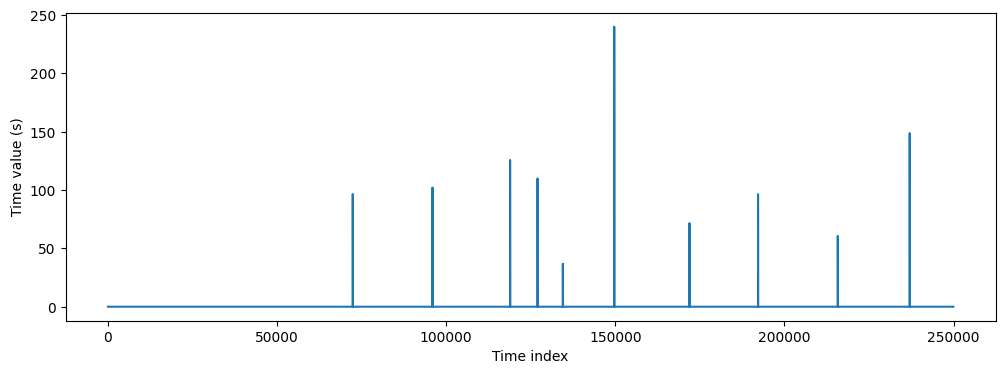

In [13]:
dt = df['timestamp'].diff().dropna()

print(f'Median dt value: {dt.median():.4f}')

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(dt)
plt.xlabel('Time index')
plt.ylabel('Time value (s)')
plt.show()

Diff of time value (dt) shows constant value of 0.0100 (100 Hz), except for where large jumps occur due to removal of Transient activity rows without repairing time values.

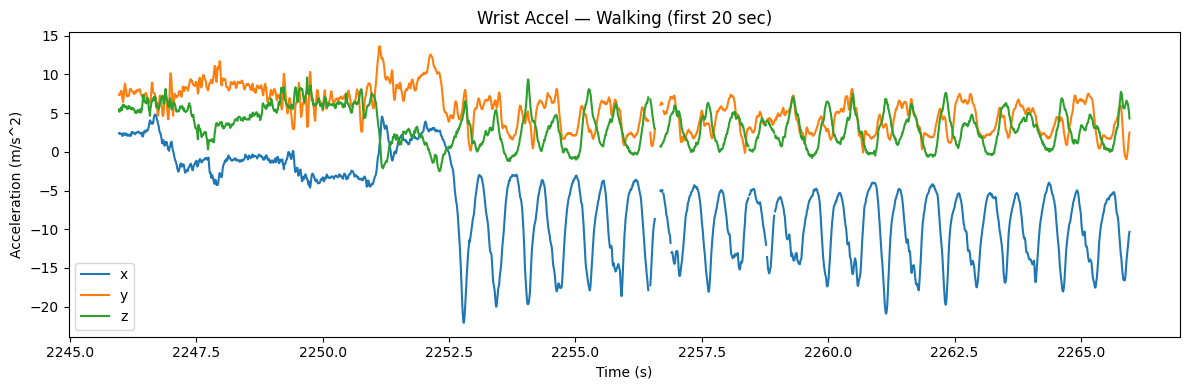

In [16]:
# Extract data for single selected activity and plot

walking = df[df['activity_id'] == 4]
fs = 100
T = 20
N = int(fs * T)

plt.figure(figsize=(12, 4))
plt.plot(walking['timestamp'].values[:N], 
         walking['hand_acc16_x'].values[:N], label='x')
plt.plot(walking['timestamp'].values[:N], 
         walking['hand_acc16_y'].values[:N], label='y')
plt.plot(walking['timestamp'].values[:N], 
         walking['hand_acc16_z'].values[:N], label='z')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title(f'Wrist Accel — Walking (first {T} sec)')
plt.legend()
plt.tight_layout()
plt.show()

### From wrist accel plot
+ Raw wrist accel signal during walking shows clear periodic structure, most pronounced in x-axis. 
+ NaN dropouts visible
+ Data looks plausible, though signal doesn't become obvious until well after labeled as "walking"
    + Might require manual time trimming of data to ensure only clean steady state activity is considered